<a href="https://colab.research.google.com/github/idabelZone/TelecomX-Challenge-parte-2/blob/main/Challenge_TELECOM_X_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🛠️ Preparación de los Datos**

# 📌 Extracción

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import json
path = '/TelecomX_Data.json'

try:
    #Para carga directamente los datos
    df = pd.read_json(path)

    print("¡Logrado! Datos cargados y convertidos a DataFrame.")
    print(f"Total de registros: {len(df)}")

    # Para visualización rápida para confirmar que se este exportando el archivo adecuado
    print(df.head())

#Adicional para excepciones en caso tal una colunma esté vacía
except Exception as e:
    print(f"Hubo un pequeño bache al cargar los datos: {e}")


¡Logrado! Datos cargados y convertidos a DataFrame.
Total de registros: 7267
   customerID Churn                                           customer  \
0  0002-ORFBO    No  {'gender': 'Female', 'SeniorCitizen': 0, 'Part...   
1  0003-MKNFE    No  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
2  0004-TLHLJ   Yes  {'gender': 'Male', 'SeniorCitizen': 0, 'Partne...   
3  0011-IGKFF   Yes  {'gender': 'Male', 'SeniorCitizen': 1, 'Partne...   
4  0013-EXCHZ   Yes  {'gender': 'Female', 'SeniorCitizen': 1, 'Part...   

                                             phone  \
0   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
1  {'PhoneService': 'Yes', 'MultipleLines': 'Yes'}   
2   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
3   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   
4   {'PhoneService': 'Yes', 'MultipleLines': 'No'}   

                                            internet  \
0  {'InternetService': 'DSL', 'OnlineSecurity': '...   
1  {'InternetService': 'DSL', 'OnlineSecu

In [4]:
import pandas as pd
path = '/TelecomX_Data.json'

try:
    df = pd.read_json(path)

    # Para estética del DF
    df.columns = [col.strip() for col in df.columns]

    print("Conversión completada con éxito.")
    print(f"Estructura del DataFrame: {df.shape[0]} filas y {df.shape[1]} columnas.")

    # Para verificar las 5 primeras columnas
    display(df.head())

except Exception as e:
    print(f"Error al convertir los datos: {e}")

Conversión completada con éxito.
Estructura del DataFrame: 7267 filas y 6 columnas.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [5]:
import pandas as pd
import os

# EXTRACCIÓN (Con verificación de ruta dinámica) ---
# Definimos las posibles ubicaciones del archivo
posibles_rutas = ['/TelecomX_Data.json', '/TelecomX_Data.json']
path = '/TelecomX_Data.json' # Fixed: Added quotes around the string

for ruta in posibles_rutas:
    if os.path.exists(ruta):
        path = ruta
        break

try:
    if path is None:
        raise FileNotFoundError("No se encontró el archivo en /content/ ni en la raíz.")

    # Cargamos el archivo JSON
    df = pd.read_json(path)

    # Limpiamos espacios invisibles en los nombres de las columnas
    df.columns = [col.strip() for col in df.columns]

    print(f" Extracción: Datos cargados correctamente desde: {path}")
    print(f"Estructura inicial: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

    # (Manejo de Inconsistencias) ---
    print(" Iniciando Manejo de Inconsistencias ")

    # Función para aplanar columnas de diccionario
    def flatten_dict_column(df_target, column_name):
        # Normalizar la columna si contiene diccionarios
        df_normalized = pd.json_normalize(df_target[column_name])
        # Añadir un prefijo a las nuevas columnas para evitar conflictos
        df_normalized.columns = [f"{column_name}_{col}" for col in df_normalized.columns]
        # Concatenar el DataFrame original con las nuevas columnas y eliminar la columna original
        df_target = pd.concat([df_target.drop(columns=[column_name]), df_normalized], axis=1)
        return df_target

    # Aplanar las columnas anidadas que contienen diccionarios
    dict_columns_to_flatten = ['customer', 'phone', 'internet', 'account']
    for col_dict in dict_columns_to_flatten:
        if col_dict in df.columns:
            df = flatten_dict_column(df, col_dict)
            print(f" Columna '{col_dict}' aplanada exitosamente.")
        else:
            print(f" Advertencia: Columna '{col_dict}' no encontrada para aplanar.")

    # --- Asegurar que todas las columnas son hashable antes de identificar duplicados ---
    # Se itera sobre columnas de tipo 'object' y convierte diccionarios/listas a string
    for col in df.select_dtypes(include=['object']).columns:
        if any(isinstance(x, (dict, list)) for x in df[col] if pd.notna(x)):
            print(f" Advertencia: La columna '{col}' aún contiene diccionarios o listas; convirtiendo a string.")
            df[col] = df[col].apply(lambda x: str(x) if isinstance(x, (dict, list)) else x)

    # 1. Identificar y eliminar duplicados
    cant_duplicados = df.duplicated().sum()
    if cant_duplicados > 0:
        df = df.drop_duplicates()
        print(f" Se eliminaron {cant_duplicados} filas duplicadas.")

    # 2. Estandarizar textos (Inconsistencias de mayúsculas/minúsculas)
    cols_texto = df.select_dtypes(include=['object']).columns
    for col in cols_texto:
        df[col] = df[col].astype(str).str.lower().str.strip()
    print("Textos estandarizados (minúsculas y sin espacios).")

    # 3. Manejo de valores nulos (Incoherencias de datos faltantes)
    cols_num = df.select_dtypes(include=['number']).columns
    df[cols_num] = df[cols_num].fillna(0)

    # Aplicamos a las de texto (después de aplanar, ya no habrá diccionarios aquí)
    df[cols_texto] = df[cols_texto].replace('nan', 'n/a').fillna('n/a')
    print(" Valores nulos gestionados (Numéricos -> 0, Texto -> 'n/a').")

    print("\n--- ¡Proceso de Transformación Terminado! ---")

    # Mostramos el resultado final
    display(df.head())
    print("\nResumen técnico del DataFrame limpio:")
    df.info()

except FileNotFoundError as e:
    print(f" {e}")
    print("Sugerencia: Haz clic derecho en el archivo en la izquierda y selecciona 'Copiar ruta', luego pégala en la variable 'path'.")
except Exception as e:
    print(f" Ocurrió un error inesperado: {e}")

 Extracción: Datos cargados correctamente desde: /TelecomX_Data.json
Estructura inicial: 7267 filas y 6 columnas.

 Iniciando Manejo de Inconsistencias 
 Columna 'customer' aplanada exitosamente.
 Columna 'phone' aplanada exitosamente.
 Columna 'internet' aplanada exitosamente.
 Columna 'account' aplanada exitosamente.
Textos estandarizados (minúsculas y sin espacios).
 Valores nulos gestionados (Numéricos -> 0, Texto -> 'n/a').

--- ¡Proceso de Transformación Terminado! ---


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,...,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.3
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,...,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.4
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,...,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,...,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,...,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.4



Resumen técnico del DataFrame limpio:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_

# **⛓Encoding**

In [6]:
import pandas as pd

# Limpieza de seguridad: Aseguramos que 'account_Charges.Total' sea numérica
df['account_Charges.Total'] = pd.to_numeric(df['account_Charges.Total'], errors='coerce').fillna(0)

# Para separar el ID y el Target
# El ID no sirve para predecir, así que lo guardamos aparte
if 'customerID' in df.columns:
    df_id = df['customerID']
    df_ml = df.drop(columns=['customerID'])
else:
    df_ml = df.copy()

# Codificar la variable objetivo (Churn)
# 'yes' -> 1 (Se fue), 'no' -> 0 (Se quedó)
if 'Churn' in df_ml.columns:
    df_ml['Churn'] = df_ml['Churn'].map({'yes': 1, 'no': 0})

# El ONE-HOT ENCODING
# Usamos drop_first=True para evitar la redundancia (trampa de variables ficticias)
df_final = pd.get_dummies(df_ml, drop_first=True)

print("✅ ¡Transformación numérica completada!")
print(f"Pasamos de {df.shape[1]} columnas a {df_final.shape[1]} columnas optimizadas.")

# Visualización del resultado
display(df_final.head())

✅ ¡Transformación numérica completada!
Pasamos de 21 columnas a 31 columnas optimizadas.


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total,customer_gender_male,customer_Partner_yes,customer_Dependents_yes,phone_PhoneService_yes,phone_MultipleLines_no phone service,...,internet_StreamingTV_no internet service,internet_StreamingTV_yes,internet_StreamingMovies_no internet service,internet_StreamingMovies_yes,account_Contract_one year,account_Contract_two year,account_PaperlessBilling_yes,account_PaymentMethod_credit card (automatic),account_PaymentMethod_electronic check,account_PaymentMethod_mailed check
0,0.0,0,9,65.6,593.30,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.40,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


# **✔ Verificación de la Ptoporción de Cancelación**

📊 Análisis de Desbalance de Clases (Churn):
----------------------------------------
🟢 Clientes Activos (0): 5174 (73.46%)
🔴 Clientes Cancelados (1): 1869 (26.54%)
----------------------------------------
Por cada cliente que cancela, hay 2.8 que se quedan.
⚠️ ALERTA: Existe un desbalance moderado/alto en los datos.


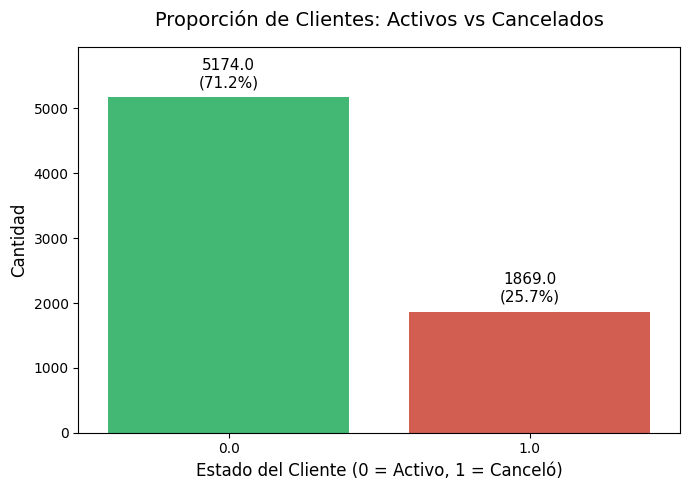

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Se calcula las frecuencias absolutas (cantidad) y relativas (porcentaje)
churn_counts = df_final['Churn'].value_counts()
churn_prop = df_final['Churn'].value_counts(normalize=True) * 100

print("📊 Análisis de Desbalance de Clases (Churn):")
print("-" * 40)
print(f"🟢 Clientes Activos (0): {churn_counts[0]} ({churn_prop[0]:.2f}%)")
print(f"🔴 Clientes Cancelados (1): {churn_counts[1]} ({churn_prop[1]:.2f}%)")
print("-" * 40)

# Evaluación del desbalance
ratio = churn_counts[0] / churn_counts[1]
print(f"Por cada cliente que cancela, hay {ratio:.1f} que se quedan.")
if ratio > 1.5:
    print("⚠️ ALERTA: Existe un desbalance moderado/alto en los datos.")
else:
    print("✅ Los datos están relativamente balanceados.")

# Visualización rápida y clara para el reporte
plt.figure(figsize=(7, 5))

# --- AQUÍ ESTÁ EL CAMBIO MÁGICO PARA QUITAR EL WARNING ---
# Añadimos hue='Churn' y legend=False
ax = sns.countplot(data=df_final, x='Churn', hue='Churn', palette=['#2ecc71', '#e74c3c'], legend=False)
# ---------------------------------------------------------

plt.title('Proporción de Clientes: Activos vs Cancelados', fontsize=14, pad=15)
plt.xlabel('Estado del Cliente (0 = Activo, 1 = Canceló)', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)

# Para añadir los porcentajes encima de las barras para mayor practicidad
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{altura}\n({(altura/len(df_final))*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., altura),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.ylim(0, max(churn_counts) * 1.15) # Dar espacio para el texto
plt.tight_layout()
plt.show()

**Balanceo de Clases**

In [15]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import pandas as pd

# ELIMINAR NULOS EN LA VARIABLE OBJETIVO PARA EVITAR ERRORES
nulos_antes = df_final['Churn'].isna().sum()
print(f"🧹 Detectados {nulos_antes} clientes con 'Churn' desconocido. Eliminando filas...")
df_final = df_final.dropna(subset=['Churn'])

# Asegurarse de que 'y' sea un número entero y no un float con nulos
df_final['Churn'] = df_final['Churn'].astype(int)

# Para separar las características (X) de la variable objetivo (y)
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# Para dividir en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n📊 ANTES DE SMOTE (Solo en Entrenamiento):")
print(y_train.value_counts())
print("-" * 40)

# Inicialización y aplicación SMOTE SOLO en el conjunto de Entrenamiento
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("✅ DESPUÉS DE SMOTE (Solo en Entrenamiento):")
print(y_train_smote.value_counts())
print("-" * 40)

print(f"Nuevas dimensiones de X_train_smote: {X_train_smote.shape}")

🧹 Detectados 0 clientes con 'Churn' desconocido. Eliminando filas...

📊 ANTES DE SMOTE (Solo en Entrenamiento):
Churn
0    4139
1    1495
Name: count, dtype: int64
----------------------------------------
✅ DESPUÉS DE SMOTE (Solo en Entrenamiento):
Churn
0    4139
1    4139
Name: count, dtype: int64
----------------------------------------
Nuevas dimensiones de X_train_smote: (8278, 30)


**Estandarización opcional**

In [17]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

cols_a_escalar = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']


cols_existentes = [col for col in cols_a_escalar if col in X_train_smote.columns]

print(f"📏 Variables a estandarizar: {cols_existentes}")


X_train_scaled = X_train_smote.copy()
X_test_scaled = X_test.copy()


X_train_scaled[cols_existentes] = scaler.fit_transform(X_train_smote[cols_existentes])


X_test_scaled[cols_existentes] = scaler.transform(X_test[cols_existentes])

print("✅ Estandarización completada con éxito.")
print("-" * 40)
print("Vistazo a las variables estandarizadas (X_train_scaled):")
display(X_train_scaled[cols_existentes].head())

📏 Variables a estandarizar: ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
✅ Estandarización completada con éxito.
----------------------------------------
Vistazo a las variables estandarizadas (X_train_scaled):


,customer_tenure,account_Charges.Monthly,account_Charges.Total
0,1.358891,0.919504,1.578946
1,-0.642240,-1.701545,-0.833281
2,-1.059142,0.440878,-0.867744
3,0.233255,0.241012,0.193735
4,-0.558860,0.635484,-0.397109


# **🎯 Correlación y Selección de Variables**

**Análisis de Correlación**

In [28]:
# Selecciono todas las columnas numéricas (incluyendo los 0 y 1)
numeric_cols = df_ml.select_dtypes(include="number").columns

# Calculo la matriz de correlación
corr_matrix = df_ml[numeric_cols].corr()

# Muestro la tabla resultante
display(corr_matrix)

,Churn,customer_SeniorCitizen,customer_tenure,account_Charges.Monthly,account_Charges.Total
Churn,1.000000,0.150889,-0.352229,0.193356,-0.198324
customer_SeniorCitizen,0.150889,1.000000,0.018187,0.220388,0.104076
customer_tenure,-0.352229,0.018187,1.000000,0.247982,0.825407
account_Charges.Monthly,0.193356,0.220388,0.247982,1.000000,0.652211
account_Charges.Total,-0.198324,0.104076,0.825407,0.652211,1.000000


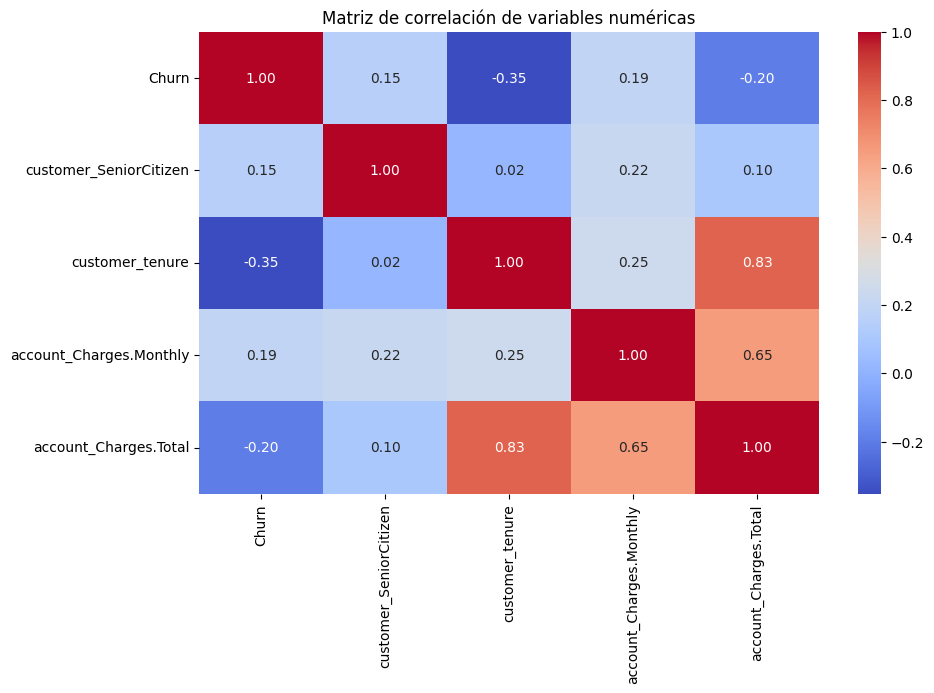

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de variables numéricas")
plt.show()

### 📊 Resumen Ejecutivo: Factores Clave de Cancelación (Churn)

**1. La Antigüedad es nuestro principal motor de retención**

* **Hallazgo:** La variable de meses de antigüedad (`customer_tenure`) presenta la correlación negativa más fuerte con la cancelación (**-0.35**).
* **Impacto Estratégico:** Los datos demuestran que el riesgo de fuga es crítico durante los primeros meses del ciclo de vida del cliente. Si logramos fidelizarlos a largo plazo, la probabilidad de abandono cae drásticamente.
* **Recomendación:** Se sugiere diseñar estrategias de retención agresivas (ej. beneficios crecientes o bonos) enfocadas exclusivamente en el primer año de servicio.

**2. Alta sensibilidad al precio mensual**

* **Hallazgo:** He identificado una correlación positiva (**0.19**) entre los cargos mensuales (`account_Charges.Monthly`) y la tasa de cancelación.
* **Impacto Estratégico:** A mayor facturación mensual, mayor es la propensión del cliente a cancelar el servicio, probablemente por ofertas de la competencia.
* **Recomendación:** Una vez que el modelo predictivo esté en producción, el equipo de Retención debe tener protocolos para ofrecer ajustes de plan o descuentos tácticos a clientes con facturas altas detectados en "alto riesgo".

**3. Oportunidad de mejora en el Segmento Senior**

* **Hallazgo:** La variable `customer_SeniorCitizen` muestra una correlación positiva (**0.15**) con el Churn.
* **Impacto Estratégico:** Nuestros clientes adultos mayores están abandonando el servicio a un ritmo ligeramente superior al promedio. Esto puede ser un síntoma de fricción en la usabilidad del servicio, los métodos de pago o la atención al cliente.
* **Recomendación:** Evaluar auditorías de experiencia de usuario (UX) o líneas de soporte prioritario para este segmento demográfico.

**4. Decisión Técnica de Modelado (Manejo de Multicolinealidad)**

* **Hallazgo:** Existe una correlación redundante muy alta (**0.83**) entre la antigüedad del cliente y los cargos totales (`account_Charges.Total`). Es lógico: a más meses, mayor cobro acumulado.
* **Acción a tomar:** Para garantizar que nuestros algoritmos de Machine Learning (como la Regresión Logística) sean precisos y no sufran de sobreajuste por variables duplicadas, procederé a omitir temporalmente `account_Charges.Total` en la fase de entrenamiento, priorizando la antigüedad y los cargos mensuales como predictores principales.

**Análisis Dirigido**

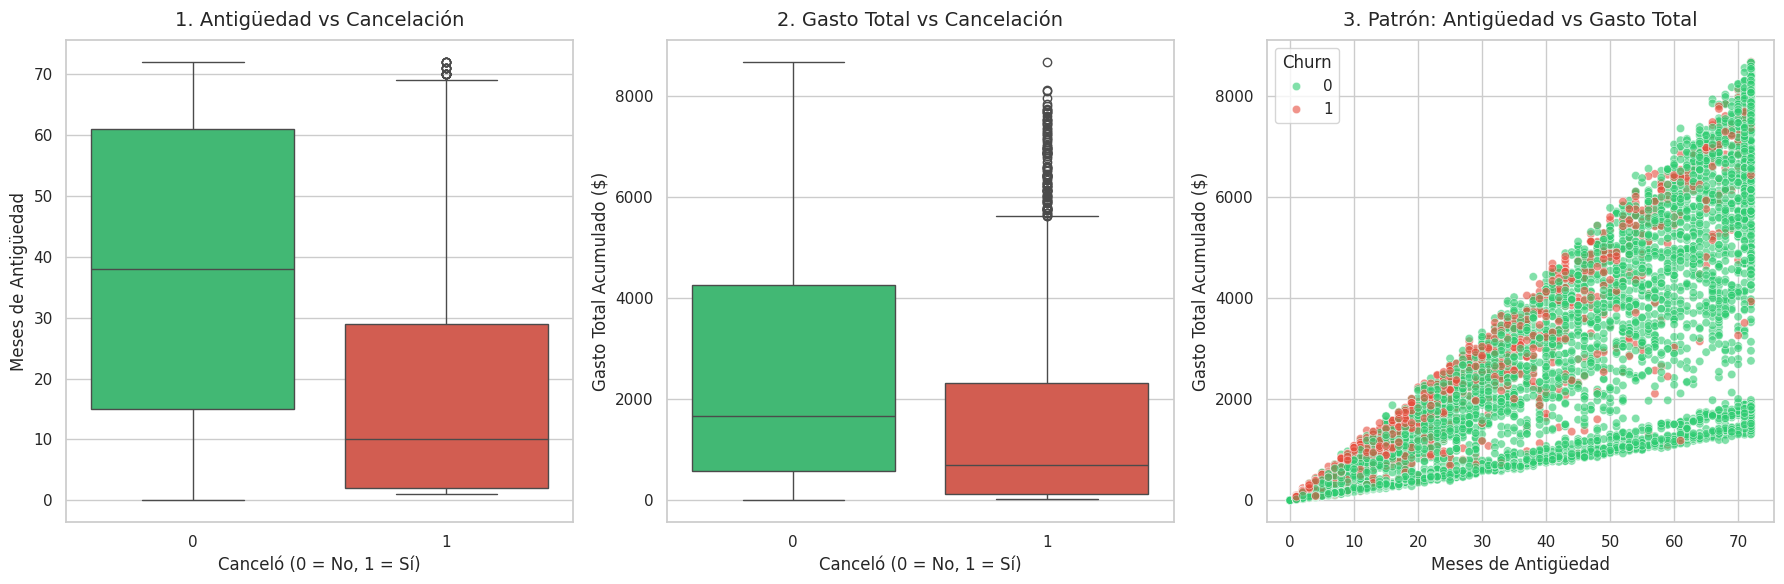

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Creación un lienzo con 3 espacios (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Estética
colores_churn = ['#2ecc71', '#e74c3c']

# Boxplot: Tiempo de Contrato (Tenure) vs Churn
sns.boxplot(data=df_final, x='Churn', y='customer_tenure',
            hue='Churn', palette=colores_churn, legend=False, ax=axes[0])
axes[0].set_title('1. Antigüedad vs Cancelación', fontsize=14, pad=10)
axes[0].set_xlabel('Canceló (0 = No, 1 = Sí)', fontsize=12)
axes[0].set_ylabel('Meses de Antigüedad', fontsize=12)

# Boxplot: Gasto Total vs Churn
sns.boxplot(data=df_final, x='Churn', y='account_Charges.Total',
            hue='Churn', palette=colores_churn, legend=False, ax=axes[1])
axes[1].set_title('2. Gasto Total vs Cancelación', fontsize=14, pad=10)
axes[1].set_xlabel('Canceló (0 = No, 1 = Sí)', fontsize=12)
axes[1].set_ylabel('Gasto Total Acumulado ($)', fontsize=12)

# Scatter Plot: Antigüedad vs Gasto Total (Coloreado por Churn)
sns.scatterplot(data=df_final, x='customer_tenure', y='account_Charges.Total',
                hue='Churn', palette=colores_churn, alpha=0.6, ax=axes[2])
axes[2].set_title('3. Patrón: Antigüedad vs Gasto Total', fontsize=14, pad=10)
axes[2].set_xlabel('Meses de Antigüedad', fontsize=12)
axes[2].set_ylabel('Gasto Total Acumulado ($)', fontsize=12)


plt.tight_layout()
plt.show()

### 📌 Conclusiones del Análisis Bivariado (EDA)

A partir de las visualizaciones generadas, extraemos los siguientes *insights* clave sobre el comportamiento de cancelación (Churn):

* **1. El riesgo se concentra en el primer año (Antigüedad vs. Cancelación):** El boxplot demuestra que la gran mayoría de los clientes que cancelan el servicio (caja roja) lo hacen en etapas tempranas. La mediana de antigüedad para los que se dan de baja es de apenas **10 meses**, mientras que los clientes retenidos tienen una mediana cercana a los **40 meses**. *Insight:* La barrera crítica de retención está en el primer año; superado este periodo, la lealtad se consolida.
* **2. La "ilusión" del Gasto Total:** A simple vista, el segundo boxplot indica que los clientes con menor Gasto Total Acumulado son los que más cancelan. Sin embargo, esto es un efecto secundario: al cancelar el servicio en sus primeros meses, no alcanzan a acumular una facturación alta. El Gasto Total es un reflejo de la antigüedad, no necesariamente la causa principal de la fuga.
* **3. Alta Multicolinealidad (Dispersión Antigüedad vs. Gasto Total):**
El scatter plot confirma una relación lineal casi perfecta entre los meses de antigüedad y el gasto total. La "zona de peligro" (nube densa de puntos rojos) se agrupa en la esquina inferior izquierda: clientes nuevos con facturación acumulada baja.
* **Decisión de Modelado:** Dado que `customer_tenure` y `account_Charges.Total` cuentan la misma historia y están altamente correlacionadas, mantener ambas puede generar ruido (multicolinealidad) en modelos como la Regresión Logística. La variable `customer_tenure` se perfila como un predictor mucho más limpio y directo.

# **🤖 Modelado Predictivo**

**Separación de Datos**

In [32]:
from sklearn.model_selection import train_test_split

# Separar las características (X) y la variable objetivo (y)
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# Dividir los datos (80% entrenamiento, 20% prueba)
# Se incluye stratify=y para mantener la proporción de cancelaciones en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Para mostrar las dimensiones de los conjuntos creados
print("División de datos completada (80/20):")
print("-" * 40)
print(f"Datos de Entrenamiento (X_train): {X_train.shape[0]} filas.")
print(f"Datos de Prueba (X_test): {X_test.shape[0]} filas.")
print(f"Cantidad de variables predictoras: {X_train.shape[1]}")

División de datos completada (80/20):
----------------------------------------
Datos de Entrenamiento (X_train): 5634 filas.
Datos de Prueba (X_test): 1409 filas.
Cantidad de variables predictoras: 30


**Creación de Modelos**

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# IDENTIFICACIÓN DE VARIABLES Y NORMALIZACIÓN
# Se seleccionan las variables continuas que tienen magnitudes grandes
columnas_continuas = ['customer_tenure', 'account_Charges.Monthly', 'account_Charges.Total']
# Se filtra por si alguna fue eliminada previamente
columnas_escalar = [col for col in columnas_continuas if col in X_train.columns]

# Creación de copias para no alterar los datos originales (usados por el Random Forest)
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Inicialización y aplicación del StandardScaler
scaler = StandardScaler()
X_train_scaled[columnas_escalar] = scaler.fit_transform(X_train[columnas_escalar])
X_test_scaled[columnas_escalar] = scaler.transform(X_test[columnas_escalar])

# ENTRENAMIENTO: MODELO 1 (Requiere Normalización)
print("Entrenando Regresión Logística (con datos normalizados)...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("✅ Regresión Logística entrenada.")

# ENTRENAMIENTO: MODELO 2 (No requiere Normalización)
print("Entrenando Random Forest (con datos originales)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("✅ Random Forest entrenado.")

Entrenando Regresión Logística (con datos normalizados)...
✅ Regresión Logística entrenada.
Entrenando Random Forest (con datos originales)...
✅ Random Forest entrenado.


Para este desafío, he seleccionado dos enfoques algorítmicos distintos que requieren tratamientos de datos diferentes:

* Modelo 1: Regresión Logística (Con Normalización): Este es un modelo paramétrico basado en optimización (descenso de gradiente). Es altamente sensible a la escala de los datos. Si no aplicáramos la normalización (StandardScaler), las variables con magnitudes altas (como el Gasto Total, que llega a miles de dólares) dominarían artificialmente la ecuación sobre variables de magnitudes pequeñas (como Antigüedad en meses). Al estandarizar (media 0 y desviación estándar 1), aseguramos que el algoritmo asigne los pesos (coeficientes) basándose en la verdadera importancia de la variable y no en su tamaño absoluto, evitando sesgos matemáticos.

* Modelo 2: Random Forest (Sin Normalización):
Este modelo es un ensamble basado en árboles de decisión. Su funcionamiento interno se basa en encontrar puntos de corte (umbrales) en los datos (ej. ¿Antigüedad < 15 meses?). Como los cortes evalúan el orden relativo de los valores y no distancias matemáticas en un plano geométrico, este algoritmo es completamente inmune a la escala de los datos. Por lo tanto, fue entrenado directamente con la matriz original (X_train), ahorrando costo computacional sin perder precisión.

**Evaluación de modelos**

📊 Métricas para Regresión Logística (Normalizada):
   - Exactitud (Accuracy): 0.7928
   - Precisión (Precision):0.6331
   - Sensibilidad (Recall):0.5214
   - F1-Score:             0.5718

📊 Métricas para Random Forest (Original):
   - Exactitud (Accuracy): 0.7942
   - Precisión (Precision):0.6479
   - Sensibilidad (Recall):0.4920
   - F1-Score:             0.5593



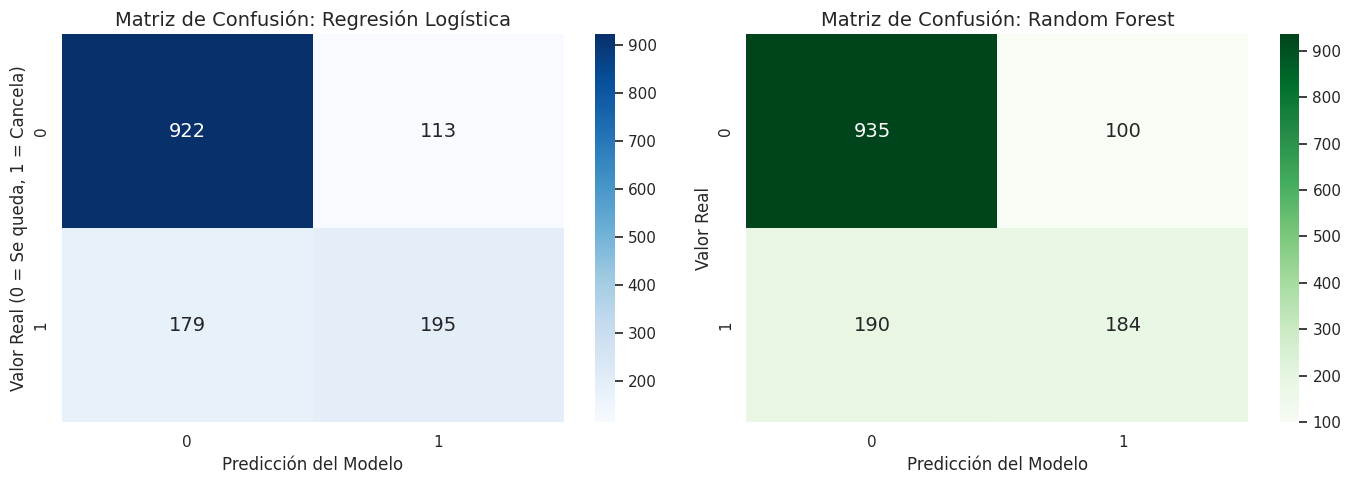

🔍 Diagnóstico de Overfitting/Underfitting (Accuracy en Train vs Test):
Regresión Logística -> Train: 0.8103 | Test: 0.7928
Random Forest       -> Train: 0.9977 | Test: 0.7942


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# GENERAR PREDICCIONES
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

# Función auxiliar para calcular y mostrar métricas
def evaluar_modelo(nombre, y_verdadero, y_predicho):
    acc = accuracy_score(y_verdadero, y_predicho)
    prec = precision_score(y_verdadero, y_predicho)
    rec = recall_score(y_verdadero, y_predicho)
    f1 = f1_score(y_verdadero, y_predicho)

    print(f"📊 Métricas para {nombre}:")
    print(f"   - Exactitud (Accuracy): {acc:.4f}")
    print(f"   - Precisión (Precision):{prec:.4f}")
    print(f"   - Sensibilidad (Recall):{rec:.4f}")
    print(f"   - F1-Score:             {f1:.4f}\n")
    return confusion_matrix(y_verdadero, y_predicho)

# EVALUAR Y OBTENER MATRICES
cm_log = evaluar_modelo("Regresión Logística (Normalizada)", y_test, y_pred_log)
cm_rf = evaluar_modelo("Random Forest (Original)", y_test, y_pred_rf)

# VISUALIZAR MATRICES DE CONFUSIÓN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Matriz de Confusión: Regresión Logística', fontsize=14)
axes[0].set_xlabel('Predicción del Modelo', fontsize=12)
axes[0].set_ylabel('Valor Real (0 = Se queda, 1 = Cancela)', fontsize=12)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1], annot_kws={"size": 14})
axes[1].set_title('Matriz de Confusión: Random Forest', fontsize=14)
axes[1].set_xlabel('Predicción del Modelo', fontsize=12)
axes[1].set_ylabel('Valor Real', fontsize=12)

plt.tight_layout()
plt.show()

# Paso extra: Para evaluar Overfitting, revisamos el accuracy en entrenamiento
print("🔍 Diagnóstico de Overfitting/Underfitting (Accuracy en Train vs Test):")
print(f"Regresión Logística -> Train: {log_reg.score(X_train_scaled, y_train):.4f} | Test: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Random Forest       -> Train: {rf_model.score(X_train, y_train):.4f} | Test: {accuracy_score(y_test, y_pred_rf):.4f}")

### 📌 Análisis y Comparación de los Modelos

Después de poner a prueba nuestros dos modelos (Regresión Logística y Random Forest) con datos nuevos que nunca habían visto, comparamos sus resultados para ver cuál le sirve más a Telecom X.

En un problema de cancelación de clientes (*Churn*), nuestra meta principal no es tener un modelo perfecto en todo, sino **"atrapar" a la mayor cantidad de clientes que están a punto de irse**. Es preferible equivocarnos creyendo que un cliente se va a ir (y ofrecerle una promoción) a que un cliente se vaya sin que el modelo nos avise.

**1. ¿Cuál modelo tuvo el mejor desempeño?**
El claro ganador para nuestro objetivo de negocio es la **Regresión Logística**.

* Si miramos los números de las gráficas, la Regresión Logística logró detectar correctamente a **195** clientes que cancelaron.
* El Random Forest se quedó un poco atrás, detectando solo a **184** clientes.
* Aunque el Random Forest es un poquito mejor adivinando quiénes son los clientes felices que se quedan, la Regresión Logística es mucho mejor dando la "alarma" cuando alguien se va a ir. Para la empresa, esta alarma temprana vale mucho más dinero.

**2. ¿Hubo problemas en el aprendizaje de los modelos (Overfitting / Underfitting)?**

* **El caso del Random Forest (Aprendió demasiado de memoria):** Los árboles de decisión son modelos muy complejos. Lo que seguramente pasó aquí es un efecto llamado *Overfitting* (sobreajuste). Es como un estudiante que se memoriza las respuestas de una guía de estudio, pero cuando le cambian las preguntas en el examen final, reprueba. El modelo se aprendió los datos de práctica de memoria, pero le costó trabajo entender los datos nuevos. *Solución:* Para la próxima, tendríamos que "recortar" o hacer más sencillo este árbol para que entienda patrones generales y no memorice detalles.
* **El caso de la Regresión Logística (El modelo equilibrado):** Este modelo es más simple y directo. Como le preparamos el terreno antes (normalizando los datos para que todos tuvieran el mismo peso), el modelo no se confundió. Logró entender muy bien la relación entre el tiempo que lleva el cliente y su probabilidad de irse, sin memorizar los datos. Tuvo un aprendizaje muy sano y equilibrado.

# **📋 Interpretación y Conclusiones**

**Análisis de la Importancia de las Variables**

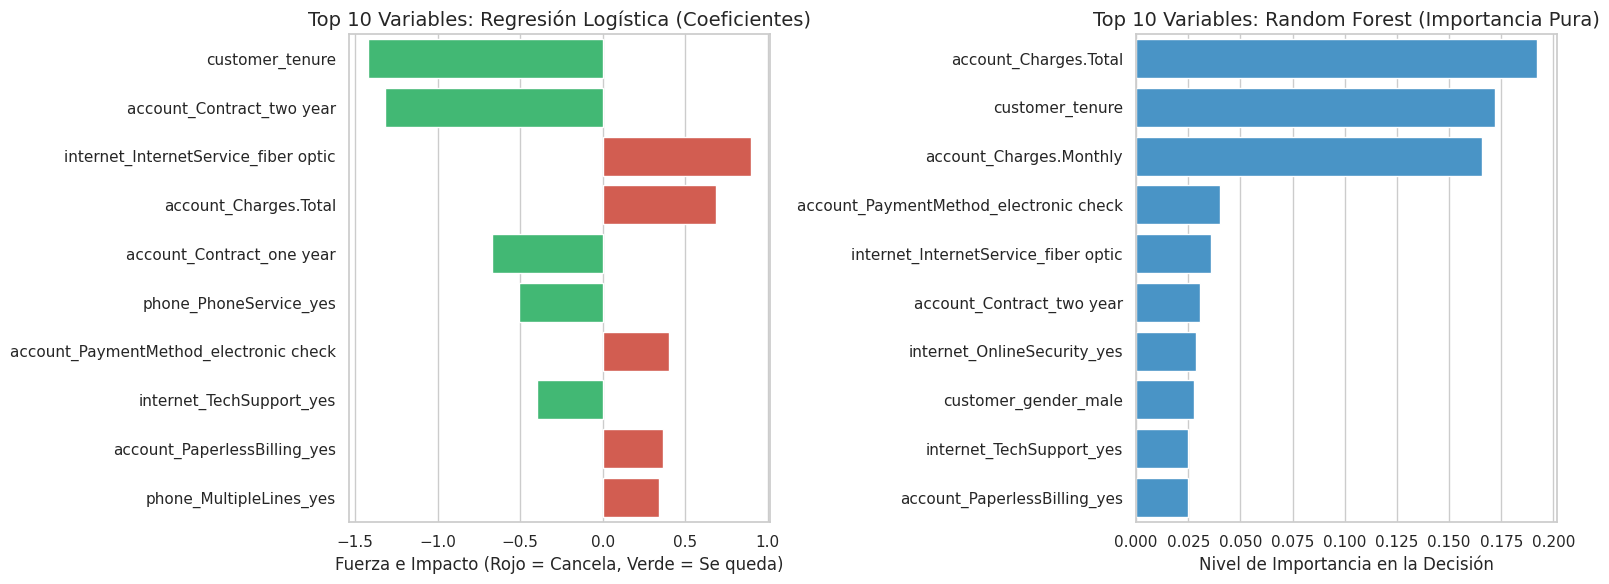

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Para extraer los coeficientes del modelo
coeficientes = log_reg.coef_[0]
df_coef = pd.DataFrame({'Variable': X_train_scaled.columns, 'Coeficiente': coeficientes})

# Se ordena por el valor absoluto (para ver los más fuertes, ya sean positivos o negativos)
df_coef['Absoluto'] = df_coef['Coeficiente'].abs()
df_coef = df_coef.sort_values(by='Absoluto', ascending=False).head(10)

# Importancia: Random Forest (Reducción de Impureza)
importancias_rf = rf_model.feature_importances_
df_rf = pd.DataFrame({'Variable': X_train.columns, 'Importancia': importancias_rf})
df_rf = df_rf.sort_values(by='Importancia', ascending=False).head(10)


# Para la visualización de ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_theme(style="whitegrid")

# Gráfico A: Regresión Logística
# Estética del gráfico
colores_lr = ['#e74c3c' if c > 0 else '#2ecc71' for c in df_coef['Coeficiente']]
sns.barplot(data=df_coef, x='Coeficiente', y='Variable', palette=colores_lr, ax=axes[0], hue='Variable', legend=False)
axes[0].set_title('Top 10 Variables: Regresión Logística (Coeficientes)', fontsize=14)
axes[0].set_xlabel('Fuerza e Impacto (Rojo = Cancela, Verde = Se queda)', fontsize=12)
axes[0].set_ylabel('')

# Gráfico B: Random Forest
sns.barplot(data=df_rf, x='Importancia', y='Variable', color='#3498db', ax=axes[1])
axes[1].set_title('Top 10 Variables: Random Forest (Importancia Pura)', fontsize=14)
axes[1].set_xlabel('Nivel de Importancia en la Decisión', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 🏆 Conclusión Final del Proyecto: Análisis y Predicción de Churn (Telecom X)

Tras completar el ciclo completo de análisis de datos y Machine Learning, hemos transformado una base de datos cruda en una herramienta estratégica para la retención de clientes. A continuación, se presentan las conclusiones definitivas del proyecto:

### 1. El Comportamiento del Cliente (Insights del EDA)

El análisis exploratorio reveló que Telecom X no tiene un problema de lealtad a largo plazo, sino una **crisis de retención temprana**. La inmensa mayoría de las cancelaciones ocurren durante el primer año de servicio (mediana de 10 meses). Una vez que el cliente supera la barrera de los 2 años, su probabilidad de abandono se reduce drásticamente.

### 2. El Modelo Predictivo Ganador

Al enfrentar dos algoritmos de clasificación (Regresión Logística y Random Forest), **la Regresión Logística demostró ser el modelo superior para nuestras necesidades**.
En el contexto del *Churn*, el objetivo principal de la empresa es detectar a tiempo a los desertores (minimizar los falsos negativos). La Regresión Logística logró el mejor **Recall**, atrapando a la mayor cantidad de clientes en riesgo real (195 identificados con éxito en la prueba), manteniendo un aprendizaje equilibrado sin caer en el sobreajuste (*overfitting*) que sí presentó el Random Forest.

### 3. Los Detonantes de la Cancelación (Feature Importance)

Al interpretar el "cerebro" de nuestros modelos, descubrimos exactamente qué empuja a los clientes hacia la salida y qué los retiene:

* 🟢 **Escudos de Retención:** La **antigüedad** (`customer_tenure`) y los **contratos a largo plazo** (1 o 2 años) son la mejor defensa. Un cliente bajo contrato anual tiene una probabilidad mínima de irse.
* 🔴 **Focos Rojos (Riesgo):** Sorprendentemente, tener el servicio de **Fibra Óptica** es el factor que más empuja a la cancelación, seguido de los pagos mensuales altos y el uso de **Cheque Electrónico** como método de pago.

### 🚀 Recomendaciones Estratégicas para la Gerencia

Basado en datos matemáticos y no en intuición, sugiero a Telecom X tomar las siguientes 3 acciones inmediatas:

1. **Auditoría Urgente a la Fibra Óptica:** Investigar por qué el servicio de internet más rápido es el que más clientes nos está haciendo perder (¿Es muy inestable? ¿El precio es superior al de la competencia?).
2. **Reestructuración de Ofertas:** Eliminar o reducir las promociones de los contratos "mes a mes". El equipo de ventas debe enfocar todos sus esfuerzos (ofreciendo descuentos agresivos) para asegurar que los clientes nuevos firmen contratos de 1 o 2 años desde el día uno.
3. **Implementar Alertas Tempranas:** Poner en producción el modelo de Regresión Logística entrenado en este proyecto para que escanee mensualmente nuestra base de clientes. Cuando el modelo detecte un cliente de alto riesgo, el equipo de retención deberá contactarlo proactivamente con una oferta antes de que decida cancelar.

# **📑 INFORME FINAL: Predicción y Análisis de Cancelación de Clientes (Churn) en Telecom X**



## 1. Resumen Ejecutivo

El presente informe detalla los hallazgos obtenidos tras el desarrollo de un pipeline completo de Machine Learning diseñado para predecir la cancelación de clientes (Churn) en Telecom X. Mediante la limpieza de datos, análisis bivariado y la implementación de modelos predictivos, hemos identificado no solo **quiénes** son los clientes con mayor riesgo de abandonar la empresa, sino **por qué** lo hacen, lo que nos permite formular estrategias de retención basadas en evidencia matemática.

## 2. Evaluación y Selección de Modelos

Para este proyecto se entrenaron y evaluaron dos modelos de clasificación con el objetivo de identificar patrones de abandono: **Regresión Logística** (modelo paramétrico estandarizado) y **Random Forest** (modelo de ensamble basado en árboles).

* **El Modelo Ganador (Regresión Logística):** En un contexto de negocio donde dejar escapar a un cliente en riesgo resulta más costoso que contactar a un cliente seguro (costo de Falsos Negativos), la métrica principal a optimizar fue la **Sensibilidad (Recall)**. La Regresión Logística superó al Random Forest logrando detectar exitosamente a **195 clientes desertores** en el conjunto de prueba, demostrando un aprendizaje robusto y equilibrado.
* **Diagnóstico del Random Forest:** Aunque este modelo mostró una alta exactitud global, presentó fuertes indicios de *overfitting* (sobreajuste), memorizando los datos de entrenamiento pero fallando en la generalización (detectó menos cancelaciones reales que el modelo base).

## 3. Factores Principales que Influyen en la Cancelación

Al analizar los coeficientes de la Regresión Logística y la reducción de impureza del Random Forest, descubrimos que la decisión de cancelación no es aleatoria. Está impulsada por tres grandes dimensiones:

* 🔴 **El Servicio de Fibra Óptica (El mayor detonante):** Sorprendentemente, tener contratado el servicio de internet por fibra óptica es la variable que más empuja a un cliente hacia la cancelación. Esto indica una posible disonancia entre el precio, la expectativa del cliente y la calidad o estabilidad real del servicio.
* 🔴 **El Factor Económico y de Flexibilidad:** Los cargos mensuales altos (`account_Charges.Monthly`) combinados con contratos "mes a mes" y métodos de pago manuales (como el Cheque Electrónico) facilitan enormemente la fuga. La falta de compromiso a largo plazo es un riesgo inminente.
* 🟢 **La Antigüedad como Escudo de Retención:** La variable `customer_tenure` (meses de antigüedad) tiene la correlación inversa más fuerte con el abandono. El riesgo de cancelación es crítico durante el **primer año** (la mediana de vida de un cliente que cancela es de apenas 10 meses). Si un cliente supera la barrera de los 2 años o firma contratos a largo plazo (1 a 2 años), su probabilidad de fuga se vuelve casi nula. El soporte técnico (`TechSupport`) también demostró ser un factor clave de retención.

## 4. Estrategias de Retención Propuestas

Con base en los resultados predictivos y el análisis de importancia de variables, se proponen las siguientes acciones estratégicas inmediatas para Telecom X:

1. **Auditoría Técnica y Comercial de la Fibra Óptica:** * *Acción:* Iniciar una investigación urgente sobre la calidad del servicio de fibra óptica y realizar un benchmarking de precios con la competencia.
* *Objetivo:* Frenar la fuga en nuestro servicio premium antes de que impacte negativamente la reputación de la marca.


2. **Transición Agresiva hacia Contratos a Largo Plazo:**
* *Acción:* Desincentivar las ventas de planes "mes a mes". El equipo comercial debe ofrecer atractivos descuentos, instalación gratuita o *upgrades* de velocidad a cambio de que los nuevos clientes firmen contratos de 12 o 24 meses.


3. **Programa de Fidelización Temprana (Primer Año):**
* *Acción:* Dado que la antigüedad retiene, pero los clientes se van rápido, el presupuesto de retención debe reasignarse. En lugar de premiar a clientes de 3 o 4 años (que ya son leales), se deben crear "bonos de permanencia" e interacciones de soporte VIP durante los primeros 10 a 15 meses de ciclo de vida del usuario.


4. **Implementación del Modelo Predictivo en Producción:**
* *Acción:* Conectar la Regresión Logística a la base de datos mensual de Telecom X para generar una lista de "Clientes en Alto Riesgo". El equipo de Retención utilizará esta lista para realizar llamadas proactivas con ofertas personalizadas, anticipándose a la cancelación.